# Graph Convolutional Network (GCN) Pipeline for ENZYMES Dataset

**Author:** Shuai Huang

## Introduction

This assignment focuses on implementing Graph Convolutional Networks (GCNs) for graph classification using the ENZYMES dataset from PyTorch Geometric. You will explore graph structures, preprocess the data, implement GCN models (both manually and using PyG), and evaluate their performance.

Please fill in the missing code between the designated markers:

    ```Python
    ### Your code starts
    ```
    and
    ```Python
    ### Your code ends
    ```


## Dataset Description

### ENZYMES Dataset Overview

The **ENZYMES dataset** is a collection of **600 graphs**, where each graph represents a **protein**.  
The **nodes** in each graph correspond to **amino acids (residues)**, and **edges** represent **spatial closeness** between residues.  
The dataset is used for **graph classification**, where the goal is to predict the **enzyme class** of each protein.  
There are **six enzyme classes** in total.

#### **Graph Structure**
Each graph has:

- **Nodes**: Amino acids (**average ~32 nodes per graph**)
- **Edges**: Spatial connectivity (**~62 edges per graph**)
- **Node Features**: **21-dimensional feature vectors per node**
- **Graph Labels**: One of **six enzyme classes**

#### **Use Cases**
This dataset is widely used in **biochemical function prediction** and is suitable for training **Graph Neural Networks (GNNs)** such as **Graph Convolutional Networks (GCN)**.


## 1. Device Selection

In [19]:
import torch
import warnings
warnings.filterwarnings("ignore")

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(torch.__version__)

Using device: cuda
2.8.0+cu129


## 2. Package Installation

To use PyTorch Geometric (PyG), we need to install PyTorch, torch_geometric, and the required dependencies.

In [21]:
# Install PyTorch (if not installed)
!pip install torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0 --index-url https://download.pytorch.org/whl/cu129

# Install PyTorch Geometric dependencies
!pip install torch-geometric torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.8.0+cu129.html

Looking in indexes: https://download.pytorch.org/whl/cu129



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu129.html



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 3. Prepare Dataset

We will download the ENZYMES dataset using TUDataset from PyTorch Geometric and prepare it for training.

In [22]:
from torch_geometric.datasets import TUDataset

# Load the ENZYMES dataset
dataset = TUDataset(root='data/ENZYMES', name='ENZYMES')

# Move the dataset to the selected device (CPU/GPU)
dataset = dataset.shuffle()

print(f"Dataset loaded: {dataset}")
print(f"Number of graphs: {len(dataset)}")
print(f"Number of classes: {dataset.num_classes}")
print(f"Node feature dimension: {dataset.num_node_features}")

Dataset loaded: ENZYMES(600)
Number of graphs: 600
Number of classes: 6
Node feature dimension: 3


## 4. Explore the Data

### Instruction:
Before training, we should explore the dataset to understand its structure:

- **Total number of graphs**
- **Number of nodes per graph**
- **Number of edges per graph**
- **Node features and labels**

In [23]:
import numpy as np

# Get basic dataset statistics
### Your code starts
num_graphs = len(dataset)
num_classes = dataset.num_classes
num_node_features = dataset.num_node_features
### Your code ends

# Collect statistics about node and edge counts
num_nodes_list = []
num_edges_list = []

for graph in dataset:
    num_nodes_list.append(graph.num_nodes)
    num_edges_list.append(graph.num_edges)

print(f"Total Graphs: {num_graphs}")
print(f"Number of Classes: {num_classes}")
print(f"Node Feature Dimension: {num_node_features}")

print(f"Avg. Nodes per Graph: {np.mean(num_nodes_list):.2f}")
print(f"Avg. Edges per Graph: {np.mean(num_edges_list):.2f}")

# Visualize the first graph
first_graph = dataset[0]
print(f"First Graph Details:\n {first_graph}")


Total Graphs: 600
Number of Classes: 6
Node Feature Dimension: 3
Avg. Nodes per Graph: 32.63
Avg. Edges per Graph: 124.27
First Graph Details:
 Data(edge_index=[2, 188], x=[48, 3], y=[1])


## 5. Preprocessing (Normalization, Splitting into Train/Validation/Test)

### Instruction:
- Shuffle the dataset before splitting.
- Normalize node features to ensure better convergence.
- Split the dataset into train (80%), validation (10%), and test (10%) sets.

In [25]:
import torch
from torch_geometric.transforms import NormalizeFeatures
from torch.utils.data import random_split

# Normalize the node features
### Your code starts
dataset = TUDataset(root="data/ENZYMES", name="ENZYMES", transform=NormalizeFeatures())
dataset = dataset.shuffle()
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
### Your code ends

print(f"Train size: {len(train_dataset)}, Validation size: {len(val_dataset)}, Test size: {len(test_dataset)}")


Train size: 480, Validation size: 60, Test size: 60


## 6. GCN Model Definition

Instruction:
We will implement two GCN models:

1. GCN by hand (using basic matrix operations)
2. GCN using PyG (utilizing torch_geometric.nn.GCNConv)

### 6.1 Implementing GCN by Hand

We will manually implement the **graph convolution operation** **without** using `torch_geometric.nn`.

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import add_self_loops, degree
from torch_geometric.nn import global_mean_pool  # For graph-level pooling

class GCNHandmade(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCNHandmade, self).__init__()
        ### Your code starts
        self.fc1 = nn.Linear(in_channels, hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, hidden_channels)
        self.classifier = nn.Linear(hidden_channels, out_channels)  # Final graph-level classification layer
        ### Your code ends

    def forward(self, x, edge_index, batch):
        ### Your code starts

        # Step 1: Add self-loops [2, edges] --> [2, edges + nodes]
        edge_index, _ = add_self_loops(edge_index)
        
        # Step 2: Compute degree matrix
        row, col = edge_index
        deg = degree(col, x.size(0), dtype=x.dtype) # [nodes] how many neighbors each node has

        # Step 3: Normalize adjacency matrix
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col] # [edges + nodes] normalize edges

        # Step 4: Message Passing [nodes, features]
        x = self.fc1(x) # [nodes, hidden]
        x = norm.view(-1,1) * x[row] # [edges, hidden]
        x = torch.zeros_like(x).scatter_add_(0, col.unsqueeze(-1).expand_as(x), x) # [nodes + edges, hidden]
        x = F.relu(x) # [nodes + edges, hidden]

        x = self.fc2(x)
        x = norm.view(-1,1) * x[row]
        x = torch.zeros_like(x).scatter_add_(0, col.unsqueeze(-1).expand_as(x), x)
        x = F.relu(x)

        # Step 5: **Graph-level pooling** (Aggregate node representations into a single vector per graph)
        x = global_mean_pool(x, batch) # [graphs, hidden]
        
        # Step 6: Final classification
        out = self.classifier(x) # [graphs, out]
    
        
        ### Your code ends

        return F.log_softmax(out, dim=1)  # Graph-level classification output


## 6.2 Implementing GCN using PyG

Now, we define a GCN model using PyG's built-in layers.

In [44]:
from torch_geometric.nn import GCNConv

from torch_geometric.nn import GCNConv, global_mean_pool

class GCNPyG(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCNPyG, self).__init__()
        ### Your code starts
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.classifier = nn.Linear(hidden_channels, out_channels) # Graph-level classifier
        ### Your code ends

    def forward(self, x, edge_index, batch): # [nodes, features]
        ### Your code starts
        
        # Step 1: apply GCN layers with activation functions
        x = self.conv1(x, edge_index) # [nodes, hidden]
        x = F.relu(x) # [nodes, hidden]

        x = self.conv2(x, edge_index) # [nodes, hidden]
        x = F.relu(x) # [nodes, hidden]

        # Step 2: Graph-level pooling (aggregate node embeddings per graph)
        x_graph = global_mean_pool(x, batch) # [graph, hidden]
        
        ### Your code ends
        
        # Final graph-level classification
        out = self.classifier(x_graph) # [graph, classes]
        return F.log_softmax(out, dim=1)



## 7. Training the Model

We will train both models using the same pipeline and store hyperparameters in a dictionary for easy tuning.

In [45]:
from tqdm import tqdm

# Define hyperparameters
hyperparams = {
    "hidden_channels": 64,
    "learning_rate": 0.01,
    "epochs": 50,
    "batch_size": 32
}

# Define loss function and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train(model, train_dataset, val_dataset):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=hyperparams["learning_rate"])
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(hyperparams["epochs"]):
        model.train()
        total_loss = 0

        for graph in tqdm(train_dataset):
            graph = graph.to(device)
            optimizer.zero_grad()
            out = model(graph.x, graph.edge_index, graph.batch)  # Pass batch indices
            loss = loss_fn(out, graph.y)  # Graph-level loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_dataset):.4f}")

    print("Training Complete!")

## 8. Evaluating the Model

We will evaluate both models and plot accuracy results.


Training GCN (Handmade)...


100%|██████████| 480/480 [00:00<00:00, 501.05it/s]


Epoch 1, Loss: 1.8010


100%|██████████| 480/480 [00:00<00:00, 527.25it/s]


Epoch 2, Loss: 1.7950


...

Epoch 49, Loss: 1.7052


100%|██████████| 480/480 [00:01<00:00, 384.82it/s]


Epoch 50, Loss: 1.7049
Training Complete!

Evaluating GCN (Handmade)...


100%|██████████| 60/60 [00:00<00:00, 999.24it/s]


Test Accuracy: 20.00%


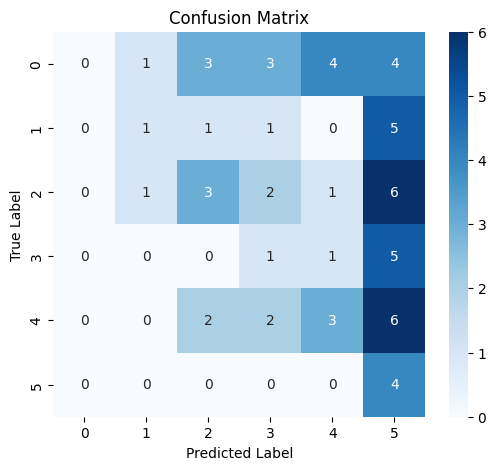

Classification Report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        15
           1     0.3333    0.1250    0.1818         8
           2     0.3333    0.2308    0.2727        13
           3     0.1111    0.1429    0.1250         7
           4     0.3333    0.2308    0.2727        13
           5     0.1333    1.0000    0.2353         4

    accuracy                         0.2000        60
   macro avg     0.2074    0.2882    0.1813        60
weighted avg     0.2107    0.2000    0.1727        60


Evaluating GCN (PyG)...


100%|██████████| 60/60 [00:00<00:00, 598.63it/s]

Test Accuracy: 18.33%


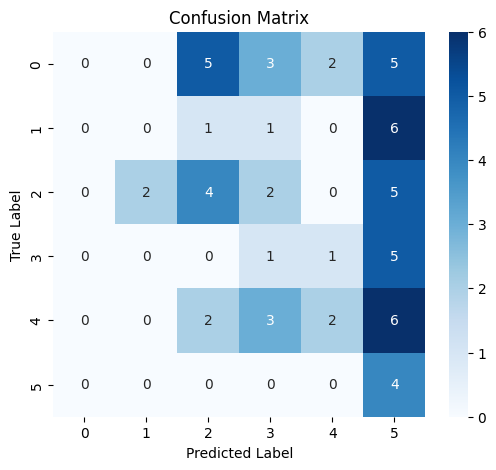

Classification Report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        15
           1     0.0000    0.0000    0.0000         8
           2     0.3333    0.3077    0.3200        13
           3     0.1000    0.1429    0.1176         7
           4     0.4000    0.1538    0.2222        13
           5     0.1290    1.0000    0.2286         4

    accuracy                         0.1833        60
   macro avg     0.1604    0.2674    0.1481        60
weighted avg     0.1792    0.1833    0.1464        60



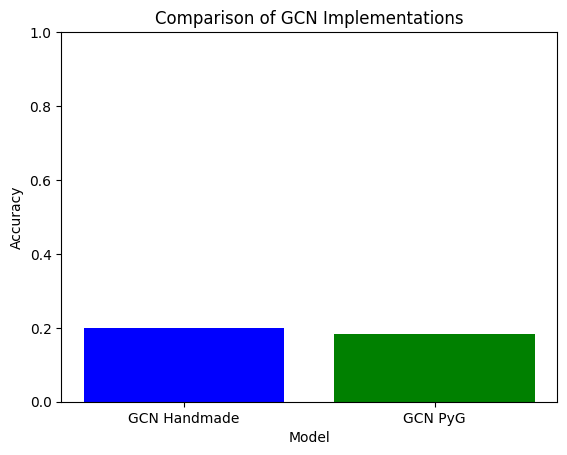

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate(model, test_dataset, name):
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0

    with torch.no_grad():
        for graph in tqdm(test_dataset):
            graph = graph.to(device)

            out = model(graph.x, graph.edge_index, graph.batch)  # **Pass batch index**
            pred = out.argmax(dim=1)
            correct += (pred == graph.y).sum().item()
            total += graph.y.size(0)

            all_preds.append(pred.item())
            all_labels.append(graph.y.item())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)


    # Metrics
    accuracy = correct / total
    print(f"Test Accuracy: {accuracy * 100:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(6), yticklabels=range(6))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.savefig(f"{name}_confusion_matrix.png", dpi=300, bbox_inches='tight')
    plt.show()

    ## Classification Report
    report = classification_report(all_labels, all_preds, zero_division=0, digits=4)
    print("Classification Report:\n", report)
    with open(f"{name}_classification_report.txt", "w") as f:
        f.write(report)

    return accuracy

# Train and evaluate both models
gcn_handmade = GCNHandmade(dataset.num_node_features, hyperparams["hidden_channels"], dataset.num_classes)
gcn_pyg = GCNPyG(dataset.num_node_features, hyperparams["hidden_channels"], dataset.num_classes)

print("\nTraining GCN (Handmade)...")
train(gcn_handmade, train_dataset, val_dataset)

print("\nTraining GCN (PyG)...")
train(gcn_pyg, train_dataset, val_dataset)

# Evaluate both models
print("\nEvaluating GCN (Handmade)...")
acc_handmade = evaluate(gcn_handmade, test_dataset,'GCNHandmade')
print("\nEvaluating GCN (PyG)...")
acc_pyg = evaluate(gcn_pyg, test_dataset,'GCNPyG')

# Plot results
models = ["GCN Handmade", "GCN PyG"]
accuracies = [acc_handmade, acc_pyg]

plt.bar(models, accuracies, color=['blue', 'green'])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Comparison of GCN Implementations")
plt.ylim([0, 1])
plt.savefig(f"GCN_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


## 9. Making Predictions

We will make predictions on test samples and visualize them.

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import seaborn as sns
import pandas as pd

def make_predictions_and_plot(model, test_dataset, name):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for graph in tqdm(test_dataset):
            graph = graph.to(device)
            out = model(graph.x, graph.edge_index, graph.batch)  # Pass batch index
            prob = torch.exp(out)  # Convert log-softmax to probabilities
            pred = prob.argmax(dim=1)

            all_preds.append(pred.item())
            all_labels.append(graph.y.item())
            all_probs.append(prob[:, 1].item())  # Probabilities for class 1 (binary case)

    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(6), yticklabels=range(6))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.savefig(f"{name}_confusion_matrix_2.png", dpi=300, bbox_inches='tight')
    plt.show()

    ## Classification Report
    report = classification_report(all_labels, all_preds, zero_division=0, digits=4)
    print("Classification Report:\n", report)
    with open(f"{name}_classification_report_2.txt", "w") as f:
        f.write(report)

    ## ROC Curve & AUC Score
    if len(set(all_labels)) == 2:  # Only compute if binary classification
        auc_score = roc_auc_score(all_labels, all_probs)
        fpr, tpr, _ = roc_curve(all_labels, all_probs)

        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
        plt.plot([0,1], [0,1], linestyle='--', color='gray')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend()
        plt.savefig(f"{name}_FPR_TPR.png", dpi=300, bbox_inches='tight')
        plt.show()
        print(f"AUC Score: {auc_score:.4f}")

    df = pd.DataFrame({
        "true_labels": all_labels,
        "predicted_labels": all_preds
    })
    df.to_csv(f"{name}_predictions.csv", index=False)

    return all_preds, all_labels



Testing GCN (Handmade)...


100%|██████████| 60/60 [00:00<00:00, 599.57it/s]


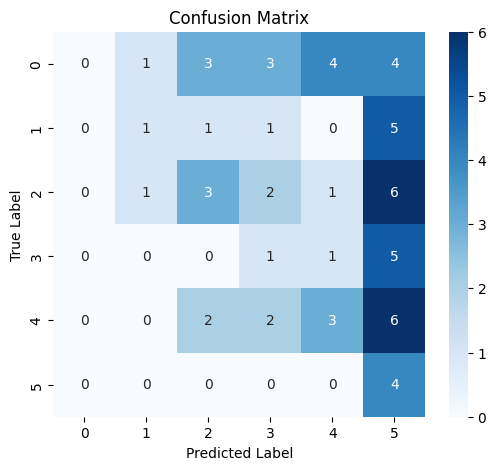

Classification Report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        15
           1     0.3333    0.1250    0.1818         8
           2     0.3333    0.2308    0.2727        13
           3     0.1111    0.1429    0.1250         7
           4     0.3333    0.2308    0.2727        13
           5     0.1333    1.0000    0.2353         4

    accuracy                         0.2000        60
   macro avg     0.2074    0.2882    0.1813        60
weighted avg     0.2107    0.2000    0.1727        60

(array([5, 3, 5, 5, 5, 5, 5, 5, 5, 4, 4, 2, 5, 1, 5, 5, 2, 4, 2, 4, 5, 5,
       2, 3, 4, 5, 4, 3, 5, 5, 1, 1, 2, 5, 5, 3, 3, 2, 5, 5, 5, 5, 3, 5,
       3, 3, 4, 2, 5, 4, 3, 4, 5, 5, 5, 2, 5, 5, 2, 5]), array([2, 2, 1, 3, 0, 3, 4, 4, 4, 3, 0, 2, 1, 1, 0, 2, 0, 0, 4, 4, 2, 0,
       2, 1, 0, 1, 0, 0, 5, 0, 0, 2, 0, 4, 5, 2, 3, 1, 2, 4, 2, 3, 0, 5,
       4, 0, 2, 2, 4, 4, 4, 4, 5, 3, 3, 4, 2, 1, 0, 1]))

Testing GCN (PyG)...


100%|██████████| 60/60 [00:00<00:00, 625.82it/s]


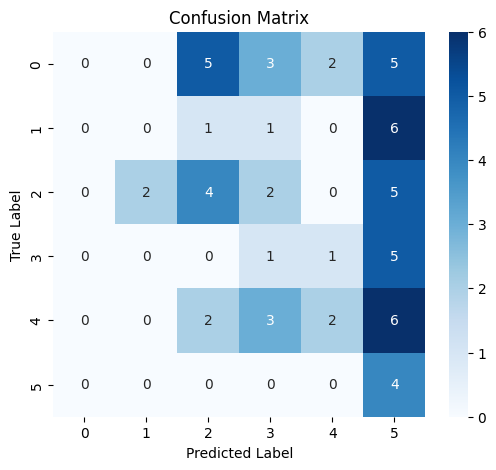

Classification Report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        15
           1     0.0000    0.0000    0.0000         8
           2     0.3333    0.3077    0.3200        13
           3     0.1000    0.1429    0.1176         7
           4     0.4000    0.1538    0.2222        13
           5     0.1290    1.0000    0.2286         4

    accuracy                         0.1833        60
   macro avg     0.1604    0.2674    0.1481        60
weighted avg     0.1792    0.1833    0.1464        60

(array([5, 1, 5, 5, 5, 5, 5, 5, 5, 4, 4, 2, 5, 5, 5, 5, 2, 2, 2, 3, 1, 5,
       2, 3, 2, 5, 4, 3, 5, 5, 5, 3, 2, 5, 5, 3, 3, 2, 5, 5, 5, 5, 3, 5,
       3, 3, 2, 2, 5, 4, 3, 4, 5, 5, 5, 2, 5, 5, 2, 5]), array([2, 2, 1, 3, 0, 3, 4, 4, 4, 3, 0, 2, 1, 1, 0, 2, 0, 0, 4, 4, 2, 0,
       2, 1, 0, 1, 0, 0, 5, 0, 0, 2, 0, 4, 5, 2, 3, 1, 2, 4, 2, 3, 0, 5,
       4, 0, 2, 2, 4, 4, 4, 4, 5, 3, 3, 4, 2, 1, 0, 1]))


In [53]:
print("\nTesting GCN (Handmade)...")
print(make_predictions_and_plot(gcn_handmade, test_dataset,'GCNHandmade'))
print("\nTesting GCN (PyG)...")
print(make_predictions_and_plot(gcn_pyg, test_dataset,'GCNPyG'))

# Key findings and observations?

Both GCNHandmade and GCNPyG performed poorly, yeilding accuracies of 20 and 18% respectively. Due to the random nature of the GCN architecture, different runs can yeild different results. Sometimes, GCNHandmade outperforms GCNpyG and vice verse. However, the accuracy is usually never above 30%. 

Looking at the classification report, some classes have a precision and recall of 0, meaning these classes were never predicted. This is true for class 0 of GCNHandmade and class 0 and 1 of GCNPyG. Meanwhile, class 5 has a recall of 1 but a precision of 0.2353 for GCNHandmade and 0.1290 for GCNPyG, implying that this class is often over-predicted. f1 is also extremely low for all 6 classes. Macro and weighted averages were also really low. These 4 observations suggest that there is class imbalance. This may be caused by the small dataset of only 600 graphs, with a 80-10-10 train-val-test split.

Ways to improve the current models include balancing out the samples for training, validating, and testing. We can also potentially add more layers in the GCN models.